# Assignment No: 04
#### Rollno. - 33157 DIV-A (TE-CS)
## Data Analytics I - Linear Regression on Boston Housing Dataset
**Dataset:** BostonHousing__1_.csv
**Source:** https://www.kaggle.com/c/boston-housing

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load Dataset
df = pd.read_csv('BostonHousing.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (506, 14)
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [4]:
# Check Missing Values and Statistics
print("Missing Values:")
print(df.isnull().sum())
print("\nStatistical Summary:")
print(df.describe().round(3))

Missing Values:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Statistical Summary:
          crim       zn    indus     chas      nox       rm      age      dis  \
count  506.000  506.000  506.000  506.000  506.000  506.000  506.000  506.000   
mean     3.614   11.364   11.137    0.069    0.555    6.285   68.575    3.795   
std      8.602   23.322    6.860    0.254    0.116    0.703   28.149    2.106   
min      0.006    0.000    0.460    0.000    0.385    3.561    2.900    1.130   
25%      0.082    0.000    5.190    0.000    0.449    5.885   45.025    2.100   
50%      0.257    0.000    9.690    0.000    0.538    6.208   77.500    3.207   
75%      3.677   12.500   18.100    0.000    0.624    6.624   94.075    5.188   
max     88.976  100.000   27.740    1.000    0.871    8.780  100.000   12.126   

           rad      tax  ptratio     

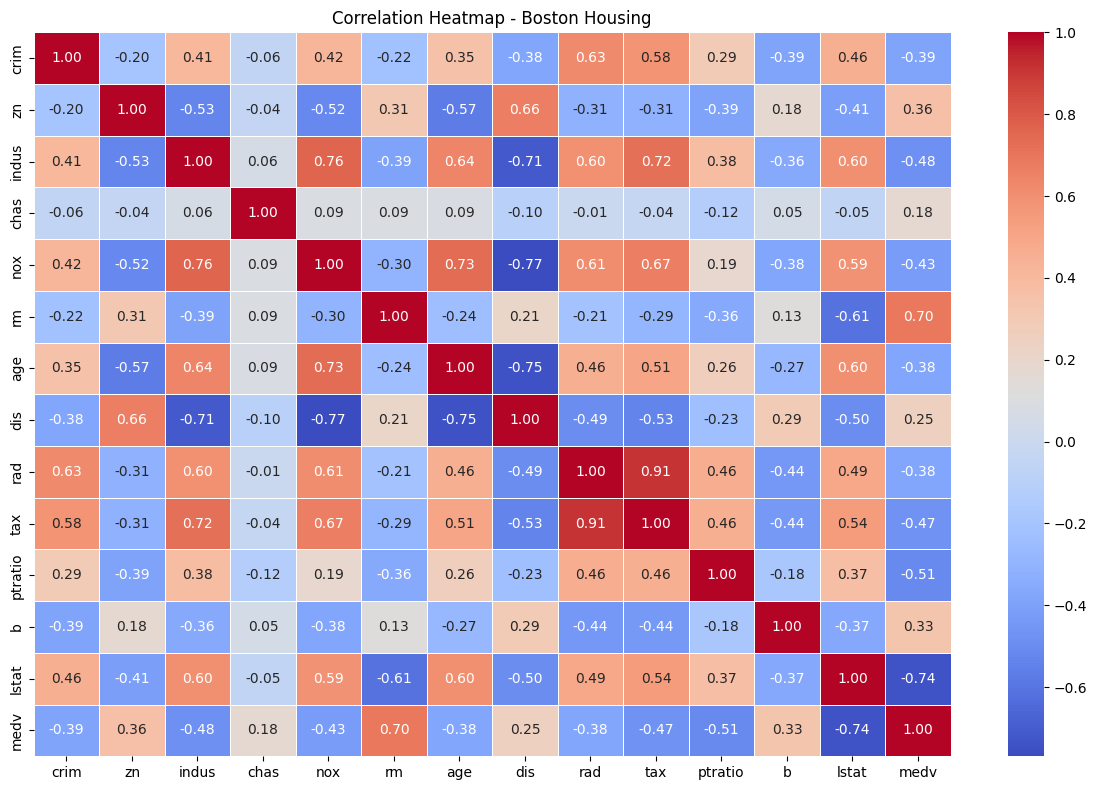

In [5]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Boston Housing')
plt.tight_layout()
plt.show()

In [6]:
# Feature and Target
X = df.drop('medv', axis=1)
y = df['medv']

# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (404, 13), Test: (102, 13)


In [7]:
# StandardScaler
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("Scaling done!")

Scaling done!


In [8]:
# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train_sc, y_train)
print("Model trained!")
print("Intercept:", round(model.intercept_, 4))
print("Coefficients:")
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_.round(4)})
print(coef_df)

Model trained!
Intercept: 22.7965
Coefficients:
    Feature  Coefficient
0      crim      -1.0021
1        zn       0.6963
2     indus       0.2781
3      chas       0.7187
4       nox      -2.0223
5        rm       3.1452
6       age      -0.1760
7       dis      -3.0819
8       rad       2.2514
9       tax      -1.7670
10  ptratio      -2.0378
11        b       1.1296
12    lstat      -3.6117


In [9]:
# Predictions and Evaluation
y_pred = model.predict(X_test_sc)

print("=== Model Performance ===")
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²   : {r2_score(y_test, y_pred):.4f}")

=== Model Performance ===
MSE  : 24.2911
MAE  : 3.1891
RMSE : 4.9286
R²   : 0.6688


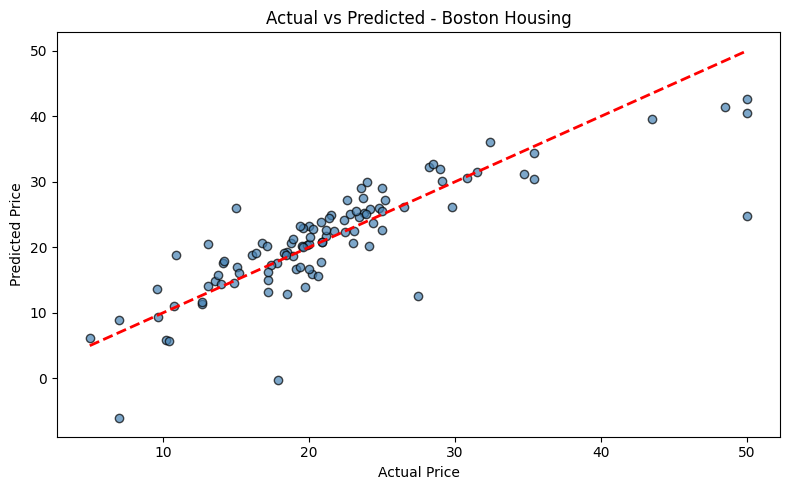

In [10]:
# Actual vs Predicted Plot
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.7, edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted - Boston Housing')
plt.tight_layout()
plt.show()

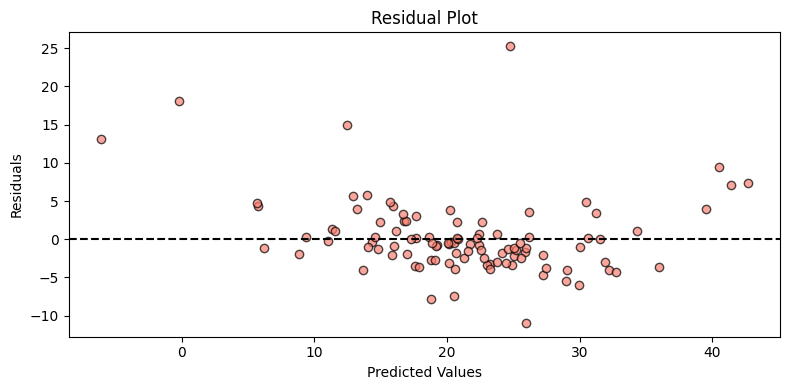

In [11]:
# Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(8,4))
plt.scatter(y_pred, residuals, color='salmon', alpha=0.7, edgecolors='black')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

In [12]:
# Sample Actual vs Predicted
result = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10].round(2)})
print(result)

   Actual  Predicted
0    23.6      29.00
1    32.4      36.03
2    13.6      14.82
3    22.8      25.03
4    16.1      18.77
5    20.0      23.25
6    17.8      17.66
7    14.0      14.34
8    19.6      23.01
9    16.8      20.63
